# BIDIRECCIONAL (modelo) 

In [2]:
import numpy as np
import pandas as pd

df_energy = pd.read_csv('EKPC_hourly.csv')
print(df_energy.shape)
print(df_energy.dtypes)
df_energy.head(10)

(45334, 2)
Datetime     object
EKPC_MW     float64
dtype: object


,Datetime,EKPC_MW
0,2013-12-31 01:00:00,1861.0
1,2013-12-31 02:00:00,1835.0
2,2013-12-31 03:00:00,1841.0
3,2013-12-31 04:00:00,1872.0
4,2013-12-31 05:00:00,1934.0
5,2013-12-31 06:00:00,1995.0
6,2013-12-31 07:00:00,2101.0
7,2013-12-31 08:00:00,2186.0
8,2013-12-31 09:00:00,2180.0
9,2013-12-31 10:00:00,2090.0


In [5]:
# Parsear fecha y ordenar cronológicamente
df_energy['Datetime'] = pd.to_datetime(df_energy['Datetime'])
df_energy = df_energy.sort_values('Datetime').reset_index(drop=True)

print(f'Rango de fechas: {df_energy["Datetime"].min()} → {df_energy["Datetime"].max()}')
print(f'Total registros: {len(df_energy)}')
print(f'\nEstadísticas:')
print(df_energy.describe())
print(df_energy.dtypes)
df_energy.head()

Rango de fechas: 2013-06-01 01:00:00 → 2018-08-03 00:00:00
Total registros: 45334

Estadísticas:
                            Datetime       EKPC_MW
count                          45334  45334.000000
mean   2016-01-01 12:59:54.679490304   1464.218423
min              2013-06-01 01:00:00    514.000000
25%              2014-09-16 08:15:00   1185.000000
50%              2016-01-01 12:30:00   1386.000000
75%              2017-04-17 18:45:00   1699.000000
max              2018-08-03 00:00:00   3490.000000
std                              NaN    378.868404
Datetime    datetime64[ns]
EKPC_MW            float64
dtype: object


,Datetime,EKPC_MW
0,2013-06-01 01:00:00,1166.0
1,2013-06-01 02:00:00,1098.0
2,2013-06-01 03:00:00,1036.0
3,2013-06-01 04:00:00,1023.0
4,2013-06-01 05:00:00,949.0


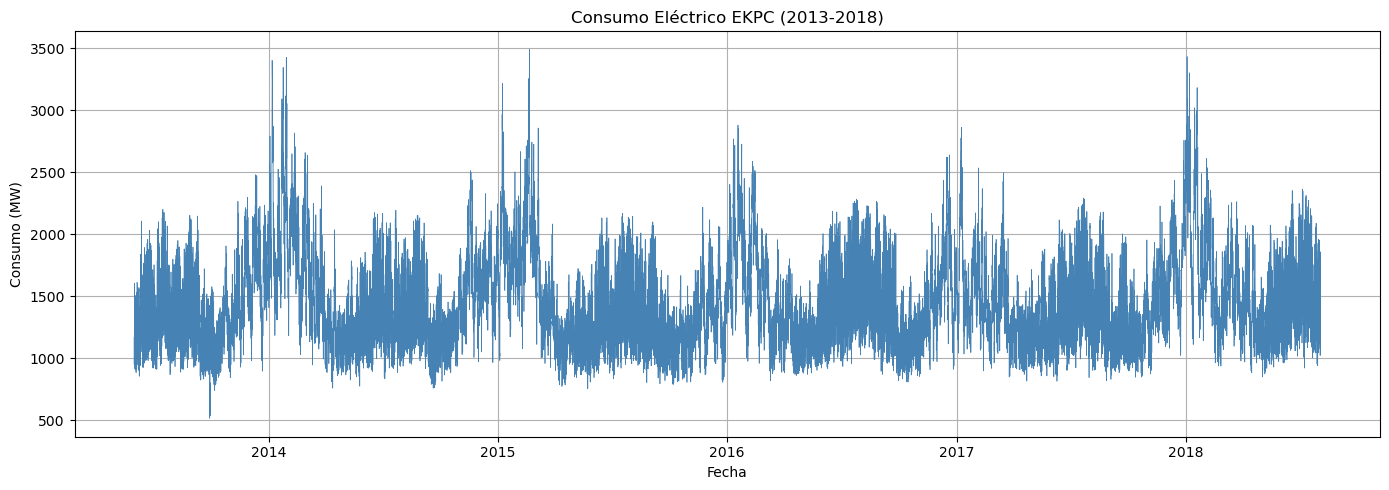

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_energy['Datetime'], df_energy['EKPC_MW'], 
         color='steelblue', linewidth=0.5)
plt.title('Consumo Eléctrico EKPC (2013-2018)')
plt.xlabel('Fecha')
plt.ylabel('Consumo (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Extraer consumo
mw = df_energy['EKPC_MW'].values.reshape(-1, 1)

# Normalizar
scaler_energy = MinMaxScaler()
mw_scaled = scaler_energy.fit_transform(mw).flatten()

# Ventana deslizante
n_steps = 24  # 24 horas de entrada

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_e, y_e = create_sequences(mw_scaled, n_steps)

# Split 70/15/15
n = len(X_e)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train_e = X_e[:n_train]
y_train_e = y_e[:n_train]
X_val_e   = X_e[n_train:n_train + n_val]
y_val_e   = y_e[n_train:n_train + n_val]
X_test_e  = X_e[n_train + n_val:]
y_test_e  = y_e[n_train + n_val:]

print(f'X_train: {X_train_e.shape}  y_train: {y_train_e.shape}')
print(f'X_val:   {X_val_e.shape}')
print(f'X_test:  {X_test_e.shape}')

X_train: (31716, 24)  y_train: (31716, 1)
X_val:   (6796, 24)
X_test:  (6798, 24)


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X[..., np.newaxis]  # (n, 24) → (n, 24, 1)
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset_bi = {
    'train': TimeSeriesDataset(X_train_e, y_train_e),
    'eval':  TimeSeriesDataset(X_val_e,   y_val_e),
    'test':  TimeSeriesDataset(X_test_e,  train=False)
}

dataloader_bi = {
    'train': DataLoader(dataset_bi['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset_bi['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset_bi['test'],  shuffle=False, batch_size=64)
}

# Verificar shapes
sample_X, sample_y = dataset_bi['train'][0]
print(f'Shape X: {sample_X.shape}')  # esperado: torch.Size([24, 1])
print(f'Shape y: {sample_y.shape}')  # esperado: torch.Size([1])
print(f'Batches train: {len(dataloader_bi["train"])}')

Shape X: torch.Size([24, 1])
Shape y: torch.Size([1])
Batches train: 496


In [ ]:
class BidirectionalLSTM(torch.nn.Module):
    def __init__(self, n_out=1):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            bidirectional=True  
        )
        # bidireccional duplica el hidden_size → 64*2=128
        self.fc = torch.nn.Linear(64 * 2, n_out)

    def forward(self, x):
        x, (h, c) = self.lstm(x)
        x = self.fc(x[:, -1])  
        return x

bilstm = BidirectionalLSTM()
print(bilstm)
total_params = sum(p.numel() for p in bilstm.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

BidirectionalLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parámetros entrenables: 133,761


In [ ]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

def fit(model, dataloader, epochs=100):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    for epoch in bar:
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
        bar.set_description(f"loss {np.mean(train_loss):.5f} val_loss {np.mean(eval_loss):.5f}")

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

Usando: cuda


In [8]:
fit(bilstm, dataloader_bi, epochs=50)

loss 0.00018 val_loss 0.00017: 100%|██████████| 50/50 [02:36<00:00,  3.12s/it]


In [9]:
from sklearn.metrics import mean_squared_error

y_pred_bi = predict(bilstm, dataloader_bi['test'])

# Desnormalizar
y_pred_bi_real = scaler_energy.inverse_transform(y_pred_bi.cpu().numpy())
y_test_bi_real = scaler_energy.inverse_transform(y_test_e)

mse_bi  = mean_squared_error(y_test_bi_real, y_pred_bi_real)
print(f'MSE:  {mse_bi:.5f}')
print(f'RMSE: {mse_bi**0.5:.4f} MW')

MSE:  1760.19727
RMSE: 41.9547 MW


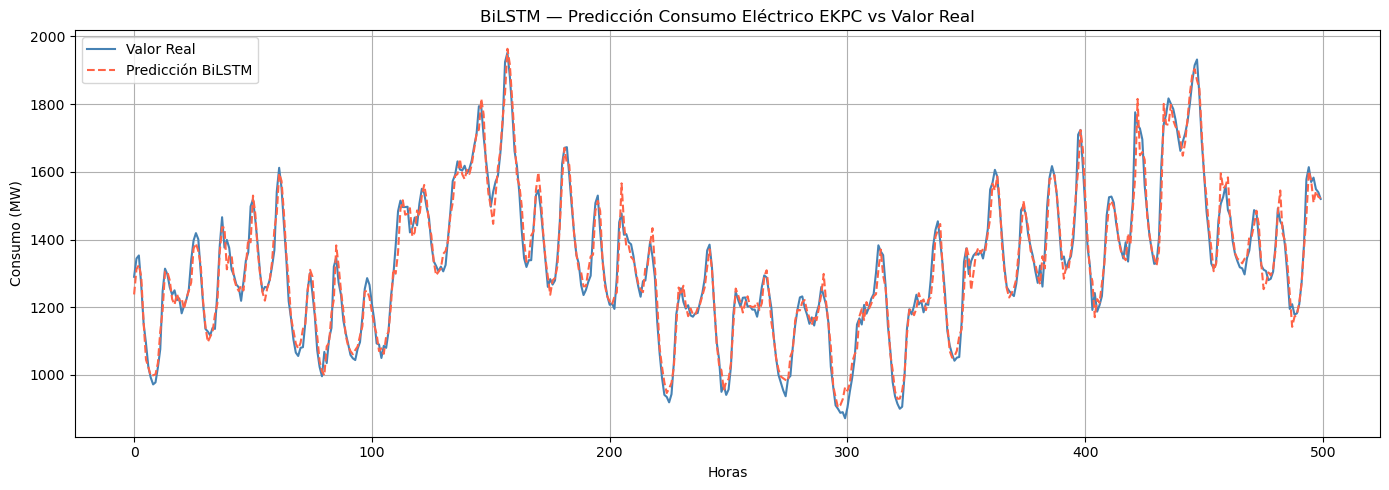

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_bi_real[:500], label='Valor Real', color='steelblue', linewidth=1.5)
plt.plot(y_pred_bi_real[:500], label='Predicción BiLSTM', color='tomato', linewidth=1.5, linestyle='--')
plt.title('BiLSTM — Predicción Consumo Eléctrico EKPC vs Valor Real')
plt.xlabel('Horas')
plt.ylabel('Consumo (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

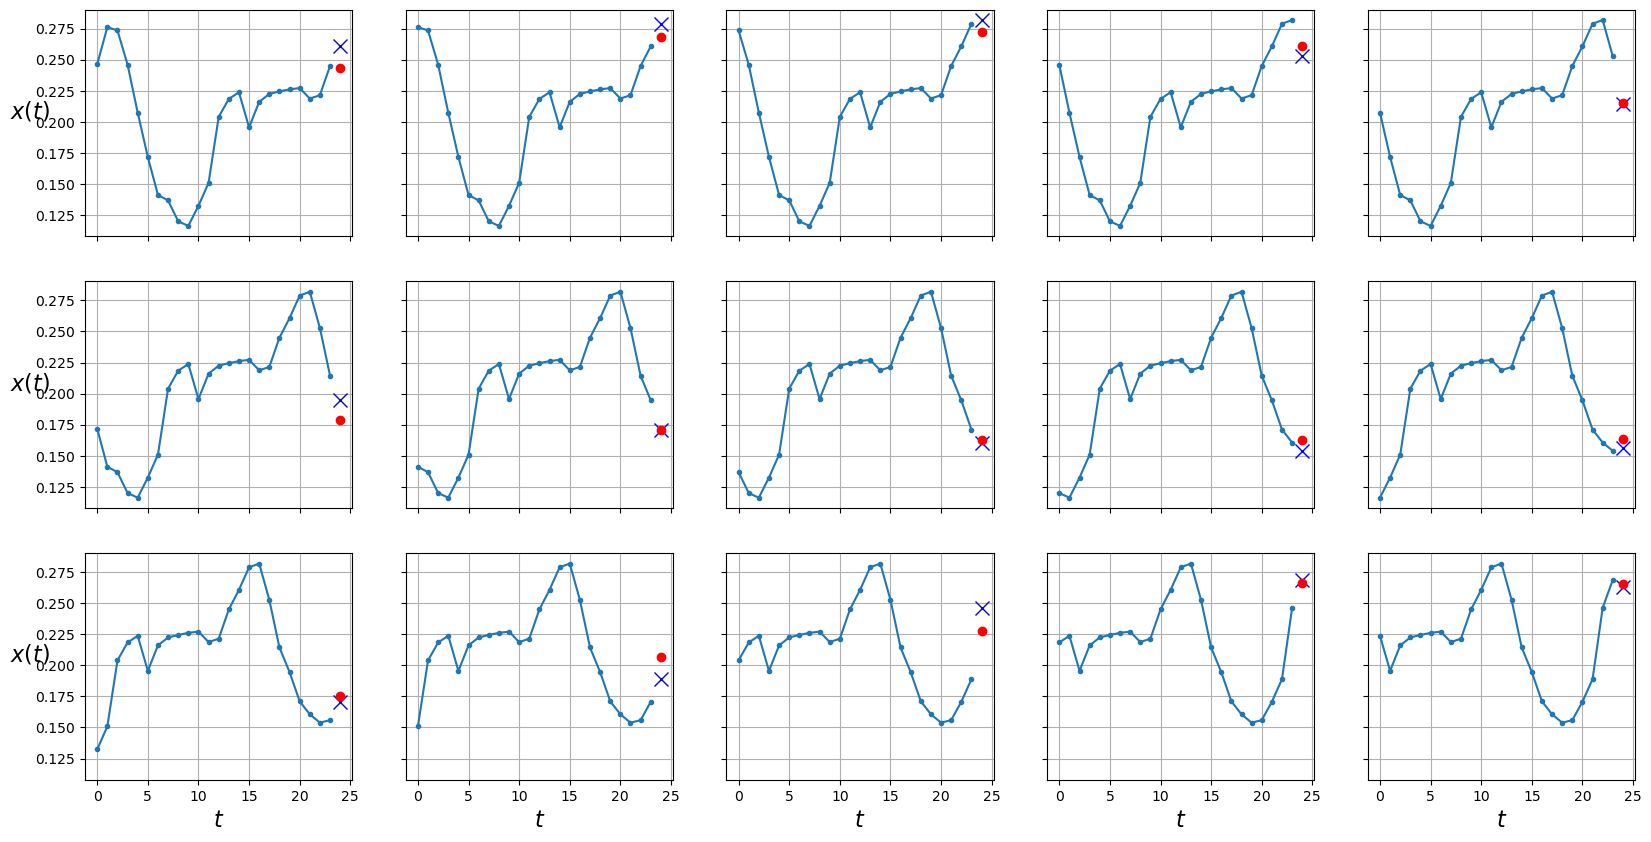

In [11]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], ".-")
            if y is not None:
                plt.plot(len(series[ix]), y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot(len(series[ix]), y_pred[ix], "ro")
            plt.grid(True)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.show()

plot_series(X_test_e[:15], y_test_e[:15], y_pred_bi.cpu().numpy()[:15])

# CONCLUSIONES

El modelo LSTM Bidireccional implementado con 2 capas, 64 neuronas ocultas por dirección y 133,761 parámetros entrenables demostró ser altamente efectivo para la predicción del consumo eléctrico horario de la cooperativa EKPC, alcanzando un RMSE de 41.95 MW sobre un consumo promedio de 1464 MW — equivalente a un error relativo del 2.86%. El dataset de 45,334 registros horarios (2013-2018) resultó ideal para este modelo por dos razones fundamentales. Primero, su gran volumen de datos permite al BiLSTM explotar plenamente su capacidad de aprendizaje de dependencias temporales de largo plazo, resolviendo el problema de vanishing gradient que afecta a las RNN simples gracias a las celdas de memoria LSTM. Segundo, la naturaleza bidireccional del modelo le permite capturar los patrones cíclicos del consumo eléctrico — diarios, semanales y anuales — procesando la secuencia tanto de pasado a futuro como de futuro a pasado, lo cual es especialmente útil en este dominio donde el consumo de una hora está influenciado simétricamente por las horas anteriores y posteriores. El val_loss de 0.00017 inferior al train_loss de 0.00018 confirma una excelente capacidad de generalización sin overfitting, validando la elección del BiLSTM para series temporales con patrones cíclicos regulares en datasets de gran volumen.